In [2]:
#importation des bibliothèques
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import plotly.express as px


In [3]:
#Charger le dataset nettoyé et afficher les informations de base
df = pd.read_csv('../data/clean/FoodWasteAI_clean.csv')
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 214 entries, 0 to 213
Data columns (total 12 columns):
 #   Column                                Non-Null Count  Dtype 
---  ------                                --------------  ----- 
 0   country                               214 non-null    object
 1   combined_figures_kg_capita_year       214 non-null    int64 
 2   household_estimate_kg_capita_year     214 non-null    int64 
 3   household_estimate_tonnes_year        214 non-null    int64 
 4   retail_estimate_kg_capita_year        214 non-null    int64 
 5   retail_estimate_tonnes_year           214 non-null    int64 
 6   food_service_estimate_kg_capita_year  214 non-null    int64 
 7   food_service_estimate_tonnes_year     214 non-null    int64 
 8   confidence_in_estimate                214 non-null    object
 9   m49_code                              214 non-null    int64 
 10  region                                214 non-null    object
 11  source                          

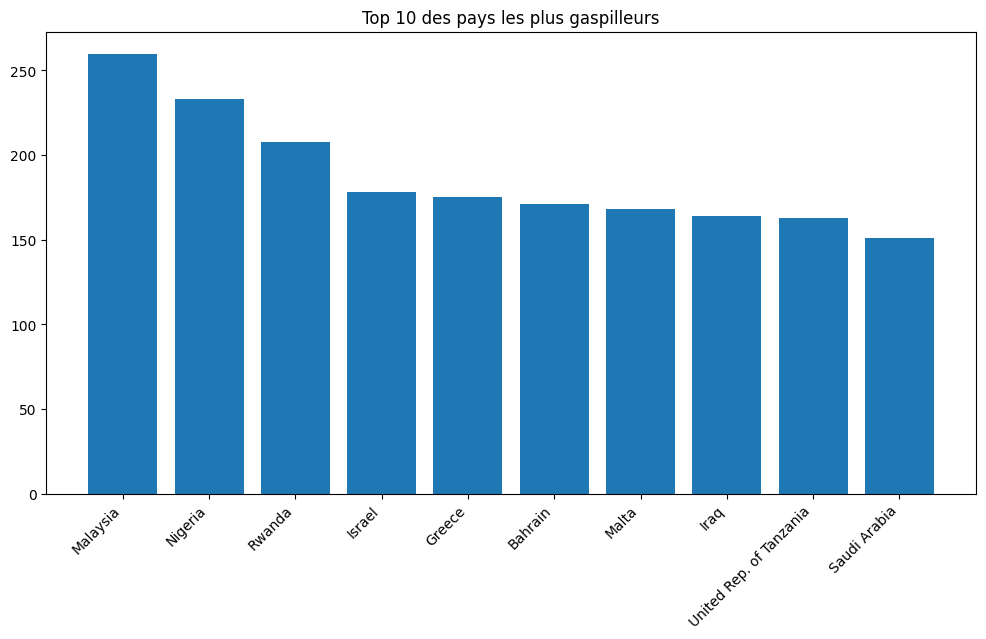

In [5]:
# Top 10 des pays les plus gaspilleurs
top10 = df.sort_values(
    by="combined_figures_kg_capita_year",
    ascending=False
).head(10)

plt.figure(figsize=(12,6))

plt.bar(
    top10["country"],
    top10["combined_figures_kg_capita_year"]
)

plt.xticks(rotation=45, ha="right")

plt.title("Top 10 des pays les plus gaspilleurs")

plt.show()

## Observation

On observe que la Malaisie présente le niveau de gaspillage alimentaire par habitant le plus élevé du dataset avec environ 260 kg par habitant et par an. Elle est suivie du Nigéria (environ 233 kg) et du Rwanda (environ 208 kg).

Les dix pays présentant les niveaux de gaspillage alimentaire par habitant les plus élevés sont : la Malaisie, le Nigéria, le Rwanda, Israël, la Grèce, Bahreïn, Malte, l'Irak, la Tanzanie et l'Arabie Saoudite.

## Interprétation

Ces pays affichent des niveaux de gaspillage alimentaire par habitant significativement plus élevés que ceux observés dans la majorité des autres pays du dataset.

Plusieurs facteurs peuvent contribuer à cette situation :

- les habitudes de consommation des ménages ;
- les pertes au niveau de la distribution et de la vente ;
- les infrastructures de stockage et de conservation ;
- le niveau de développement économique ;
- les comportements d'achat et de consommation alimentaire.

On remarque également que la Malaisie se distingue nettement des autres pays avec un niveau de gaspillage particulièrement élevé.

## Conclusion

L'analyse met en évidence d'importantes disparités entre les pays en matière de gaspillage alimentaire par habitant. La Malaisie, le Nigéria et le Rwanda figurent parmi les pays les plus concernés dans ce dataset.

Ces résultats soulignent l'importance de mettre en place des stratégies de réduction du gaspillage alimentaire adaptées à chaque contexte national. Ils constituent également une base intéressante pour le développement de modèles d'intelligence artificielle capables d'identifier les facteurs associés aux niveaux élevés de gaspillage alimentaire.

region
Sub-Saharan Africa                 145.395833
Western Asia                       145.388889
South-eastern Asia                 137.454545
Northern Africa                    133.500000
Central Asia                       130.200000
Melanesia                          128.600000
Micronesia                         123.142857
Southern Europe                    123.000000
Northern America                   120.750000
Polynesia                          119.500000
Latin America and the Caribbean    115.547619
Southern Asia                      113.111111
Eastern Asia                       113.000000
Northern Europe                    111.666667
Australia and New Zealand          111.500000
Eastern Europe                     109.400000
Western Europe                     104.888889
Name: combined_figures_kg_capita_year, dtype: float64


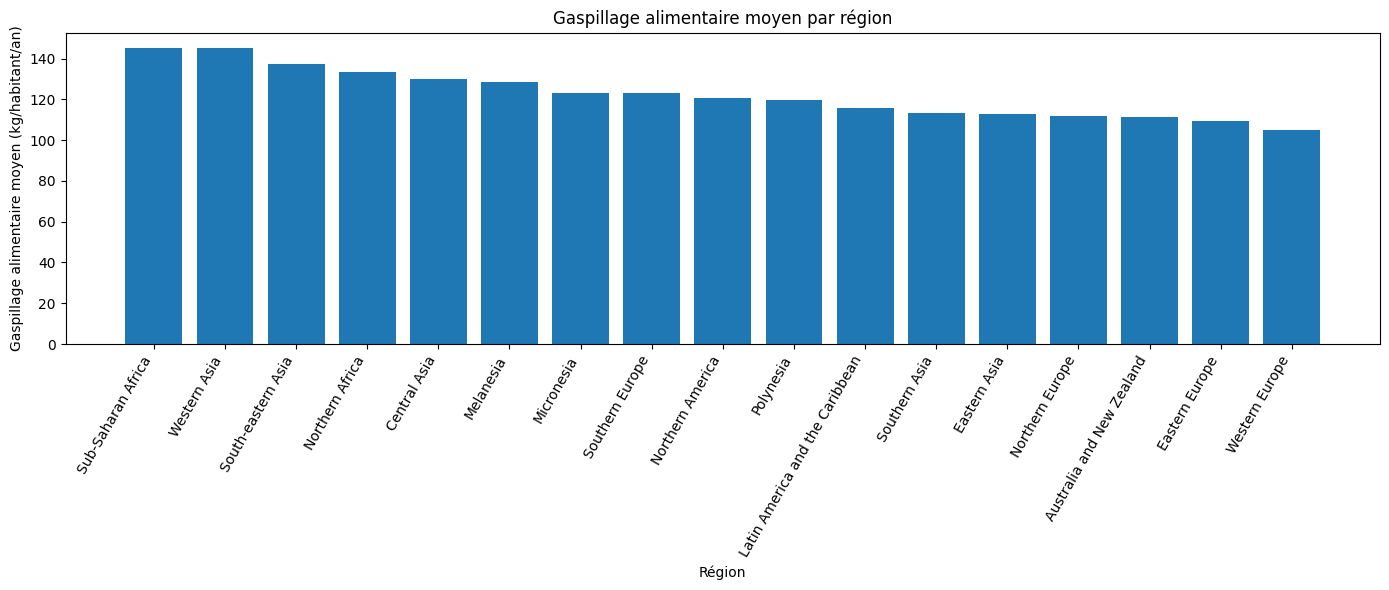

In [9]:
# Gaspillage alimentaire moyen par région

region_mean = (
    df.groupby("region")["combined_figures_kg_capita_year"]
    .mean()
    .sort_values(ascending=False)
)

plt.figure(figsize=(14, 6))

plt.bar(
    region_mean.index,
    region_mean.values
)

plt.title("Gaspillage alimentaire moyen par région")
plt.xlabel("Région")
plt.ylabel("Gaspillage alimentaire moyen (kg/habitant/an)")

plt.xticks(rotation=60, ha="right")

plt.tight_layout()
print(region_mean)

plt.show()

## Observation

On observe que les différentes régions du monde présentent des niveaux moyens de gaspillage alimentaire relativement proches. Certaines régions affichent néanmoins une moyenne légèrement supérieure à d'autres.

Les écarts observés entre les régions restent globalement modérés, ce qui suggère que le gaspillage alimentaire est un phénomène présent à l'échelle mondiale.

## Interprétation

Cette répartition relativement homogène peut s'expliquer par le fait que le gaspillage alimentaire touche aussi bien les pays développés que les pays en développement.

Les différences observées peuvent être liées à plusieurs facteurs :

- les habitudes de consommation ;
- le niveau de développement économique ;
- les infrastructures de stockage et de distribution ;
- les politiques de gestion des déchets ;
- les pratiques de production et de commercialisation alimentaire.

## Conclusion

L'analyse par région montre que le gaspillage alimentaire est un enjeu mondial qui concerne l'ensemble des régions étudiées.

Même si certaines régions présentent des niveaux légèrement plus élevés, aucune région ne se distingue de manière extrêmement marquée. Les actions de réduction du gaspillage alimentaire doivent donc être envisagées à l'échelle internationale tout en tenant compte des spécificités locales.

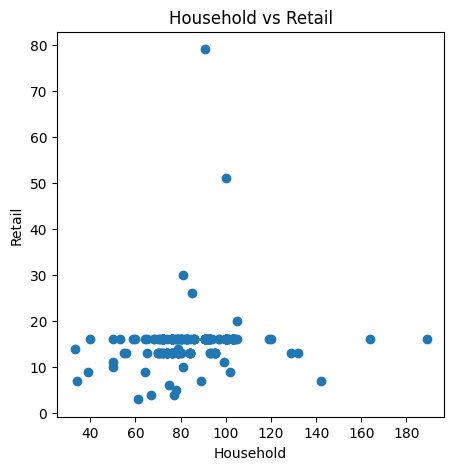

In [ ]:
#Existe-t-il une relation entre le gaspillage domestique et le gaspillage dans les commerces ?
plt.figure(figsize=(8,6))

plt.scatter(
    df["household_estimate_kg_capita_year"],
    df["retail_estimate_kg_capita_year"]
)

plt.xlabel("Household")
plt.ylabel("Retail")

plt.title(
    "Household vs Retail"
)

plt.show()

## Observation

On observe une dispersion importante des points sur le graphique. La majorité des pays présentent un gaspillage dans le commerce compris entre 10 et 20 kg par habitant et par an, même lorsque le gaspillage domestique varie fortement.

Quelques valeurs atypiques  sont également visibles, notamment des pays présentant un niveau de gaspillage dans le commerce particulièrement élevé par rapport aux autres observations.

## Interprétation

Le graphique ne montre pas de relation linéaire forte entre le gaspillage domestique et le gaspillage dans les commerces.

En effet, certains pays ayant un niveau élevé de gaspillage domestique n'affichent pas nécessairement un niveau élevé de gaspillage dans le commerce. Cela suggère que ces deux formes de gaspillage peuvent être influencées par des facteurs différents tels que :

- les habitudes de consommation des ménages ;
- les pratiques de gestion des stocks des commerces ;
- les infrastructures de distribution alimentaire ;
- les politiques de réduction du gaspillage alimentaire.

La présence de quelques valeurs atypiques indique également que certains pays possèdent des caractéristiques particulières qui mériteraient une analyse plus approfondie.

## Conclusion

L'analyse visuelle suggère qu'il n'existe pas de relation forte entre le gaspillage alimentaire des ménages et celui des commerces dans ce dataset.

Pour confirmer cette observation, il serait pertinent de calculer le coefficient de corrélation entre ces deux variables et d'examiner plus en détail les pays présentant des valeurs atypiques.

In [11]:
#Quelles variables sont les plus liées au gaspillage alimentaire total ?
correlation = df.corr(
    numeric_only=True
)

correlation[
    "combined_figures_kg_capita_year"
].sort_values(
    ascending=False
)

combined_figures_kg_capita_year         1.000000
household_estimate_kg_capita_year       0.871324
retail_estimate_kg_capita_year          0.555106
food_service_estimate_kg_capita_year    0.460778
household_estimate_tonnes_year          0.052237
m49_code                                0.044763
food_service_estimate_tonnes_year      -0.015442
retail_estimate_tonnes_year            -0.017693
Name: combined_figures_kg_capita_year, dtype: float64

## Observation

On observe que la variable la plus fortement corrélée au gaspillage alimentaire total est le gaspillage des ménages (`household_estimate_kg_capita_year`) avec un coefficient de corrélation de 0,87.

Le gaspillage dans les commerces (`retail_estimate_kg_capita_year`) et dans les services alimentaires (`food_service_estimate_kg_capita_year`) présentent également des corrélations positives, respectivement de 0,55 et 0,46.

## Interprétation

Ces résultats indiquent que le gaspillage des ménages constitue le principal facteur associé au gaspillage alimentaire total dans le dataset.

Les commerces et les services alimentaires contribuent également au phénomène, mais leur influence semble moins importante que celle des ménages.

## Conclusion

Le gaspillage alimentaire des ménages apparaît comme la variable la plus déterminante du gaspillage alimentaire total. Les stratégies de réduction du gaspillage devraient donc cibler prioritairement les comportements de consommation et de gestion alimentaire au niveau des foyers.

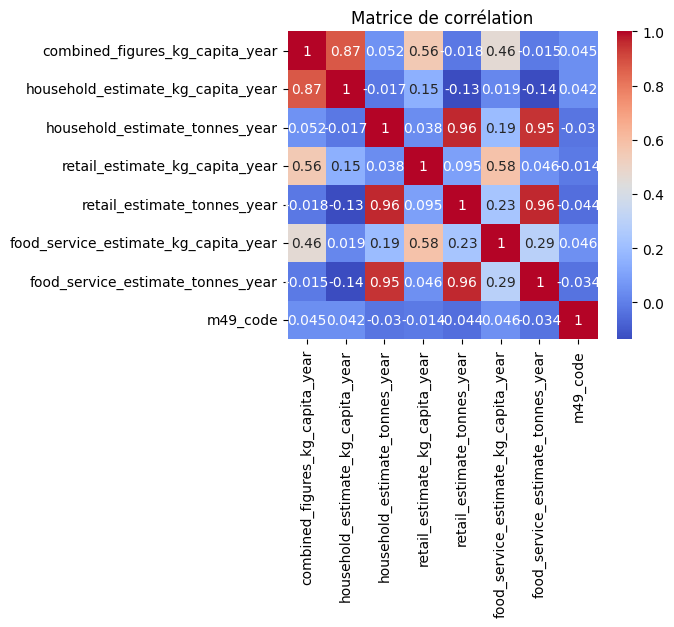

In [14]:
# Quelles relations existent entre toutes les variables du dataset ?

plt.figure(figsize=(5, 4))

sns.heatmap(
    correlation,
    annot=True,
    cmap="coolwarm"
)

plt.title("Matrice de corrélation")

plt.show()

## Observation

La matrice de corrélation met en évidence plusieurs relations importantes entre les variables du dataset.

On observe une très forte corrélation positive entre le gaspillage alimentaire total par habitant (`combined_figures_kg_capita_year`) et le gaspillage des ménages (`household_estimate_kg_capita_year`) avec un coefficient de **0,87**.

Le gaspillage alimentaire total présente également une corrélation positive modérée avec le gaspillage dans les commerces (`retail_estimate_kg_capita_year`) de **0,56** et avec le gaspillage dans les services alimentaires (`food_service_estimate_kg_capita_year`) de **0,46**.

Par ailleurs, les variables exprimées en tonnes sont fortement corrélées entre elles, notamment :

- `household_estimate_tonnes_year` et `retail_estimate_tonnes_year` : **0,96**
- `retail_estimate_tonnes_year` et `food_service_estimate_tonnes_year` : **0,96**
- `household_estimate_tonnes_year` et `food_service_estimate_tonnes_year` : **0,95**

## Interprétation

Ces résultats indiquent que le gaspillage alimentaire des ménages constitue le facteur le plus fortement associé au gaspillage alimentaire total dans les pays étudiés.

Les commerces et les services alimentaires participent également au gaspillage global, mais leur influence semble moins importante que celle des ménages.

Les très fortes corrélations observées entre les variables exprimées en tonnes suggèrent que les pays générant de grandes quantités de déchets alimentaires dans un secteur ont tendance à produire également des quantités importantes dans les autres secteurs.

## Conclusion

L'analyse de la matrice de corrélation montre que le gaspillage des ménages est la composante la plus liée au gaspillage alimentaire total.

Cette information est particulièrement importante pour le développement d'une solution d'intelligence artificielle visant à réduire le gaspillage alimentaire, car elle permet d'identifier les variables les plus pertinentes à prendre en compte dans les analyses et les futurs modèles prédictifs.